# Statistical Analysis of Radioastron OJ287 Observations

## Imports

**Comment**: Below are provided imports.

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

## Methods

**Comment**: Below are provided additional global methods to use in the Notebook.

In [69]:
def jd_from_datetime(dt):
    if pd.isna(dt):
        return np.nan
    year = dt.year
    month = dt.month
    day = dt.day
    hour = dt.hour + dt.minute/60.0 + dt.second/3600.0
    
    if month <= 2:
        year -= 1
        month += 12
    A = year // 100
    B = 2 - A + (A // 4)
    jd = int(365.25 * (year + 4716)) + int(30.6001 * (month + 1)) + day + B - 1524.5
    jd += hour / 24.0
    return jd

## Globals

**Comment**: Below are provided global variables.

In [70]:
# description of observational frequency bands
# P -- 316 MHz
# L -- 1668 MHz
# C -- 4828 MHz
# K -- 22236 MHz

bands = ['P', 'L', 'C', 'K']
bands_without_p = ['L', 'C', 'K']

# designation of colors for corresponding frequency bands
band_colors = {
    'L': "#c3ff74",
    'C': "#a6f7e3",
    'K': "#86b9c9"
}

## Data Loading & Preparation

### Data Loading

**Comment**: Load datasets.

In [71]:
df = pd.read_csv('Observations_Table.txt', sep='\t')
ang = pd.read_csv('Data_Table.txt', sep='\t')
flux = pd.read_csv('AAVSO_Light_Curve.txt', sep='\t')
ratan = pd.read_csv('RATAN_Light_Curves.txt', sep='\t')
fermit = pd.read_csv('FermiLAT_Light_Curve.txt', sep='\t')
swift = pd.read_csv('Swift_Light_Curve.txt', sep='\t')

**Comment**: Get basic information about datasets.

#### Observations Table

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         92 non-null     object 
 1   Start date/time   92 non-null     object 
 2   Stop date/time    92 non-null     object 
 3   Telescopes        92 non-null     object 
 4   BL, (ED)          92 non-null     float64
 5   Bands             92 non-null     object 
 6   Tracking station  54 non-null     object 
 7   P                 92 non-null     object 
 8   L                 92 non-null     object 
 9   C                 92 non-null     object 
 10  K                 92 non-null     object 
dtypes: float64(1), object(10)
memory usage: 8.0+ KB


In [73]:
df.head()

,Obs. Code,Start date/time,Stop date/time,Telescopes,"BL, (ED)",Bands,Tracking station,P,L,C,K
0,raes03f,21.02.2012 1:30,21.02.2012 2:30,"GRT:Eb (C),Ys (C),Mc (L),Ev (L)",12.0,CL,NaN,x,0,1,x
1,raes03i,17.03.2012 15:00,17.03.2012 16:00,"GRT:Nt,Ev,Mc,Us",10.0,LC,NaN,x,2,0,x
2,raes03p,04.04.2012 18:30,04.04.2012 19:30,"GRT:Ef (C),Ys(C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
3,raes03q,05.04.2012 17:00,05.04.2012 18:00,"GRT:Ef (C),Ys (C),Nt (C),Ev (L)",5.0,CL,NaN,x,1,1,x
4,raes03aa,27.04.2012 21:30,27.04.2012 23:30,GRT:Ar (C: 21:30-22:00; L: 22:05-22:30; P: 22:...,12.0,CLP,NaN,0,1,1,x


#### Angular Size Table

In [74]:
ang.head()

,Obs,Band,Date,Frequency,Theta_rad,Theta_rad_err,Theta_mas,Theta_mas_err,Y0,Y0_err,A0,A0_err
0,RAES03AA,C,2012-04-27,4828,5.623820e-10,6.043870e-12,0.116,0.001,0.00000,0.00000,1.82470,0.01301
1,RAES03AB,C,2012-04-28,4828,8.223090e-10,3.783600e-11,0.170,0.008,0.00000,0.00000,1.41168,0.01634
2,RAES03FW,C,2012-11-19,4828,3.105990e-09,9.651350e-10,0.641,0.199,0.04239,0.00535,2.34019,0.29095
3,RAES03FW,L,2012-11-19,1668,2.360400e-09,3.565680e-11,0.487,0.007,0.00000,0.00000,1.65010,0.00562
4,RAES03P,C,2012-04-04,4828,1.197850e-09,8.629210e-11,0.247,0.018,0.00000,0.00000,3.60793,0.05398


In [75]:
# Приводим коды наблюдений к единому виду
df["Obs_upper"] = df["Obs. Code"].str.upper().str.strip()
ang["Obs_upper"] = ang["Obs"].str.upper().str.strip()

# Добавляем BL_ED и столбцы с типами корреляции
ang = ang.merge(
    df[["Obs_upper", "BL, (ED)", "L", "C", "K", "P"]]
      .rename(columns={"BL, (ED)": "BL_ED"}),
    on="Obs_upper",
    how="left"
)

# Для каждой строки берем значение из столбца,
# название которого совпадает с Band
ang["Corr"] = ang.apply(lambda row: row[row["Band"]], axis=1)

# Удаляем ненужные служебные столбцы
ang = ang.drop(columns=["Obs_upper", "L", "C", "K", "P"])

In [76]:
print(ang.head())
print(ang.tail())

        Obs Band        Date  Frequency     Theta_rad  Theta_rad_err  \
0  RAES03AA    C  2012-04-27       4828  5.623820e-10   6.043870e-12   
1  RAES03AB    C  2012-04-28       4828  8.223090e-10   3.783600e-11   
2  RAES03FW    C  2012-11-19       4828  3.105990e-09   9.651350e-10   
3  RAES03FW    L  2012-11-19       1668  2.360400e-09   3.565680e-11   
4   RAES03P    C  2012-04-04       4828  1.197850e-09   8.629210e-11   

   Theta_mas  Theta_mas_err       Y0   Y0_err       A0   A0_err  BL_ED Corr  
0      0.116          0.001  0.00000  0.00000  1.82470  0.01301   12.0    1  
1      0.170          0.008  0.00000  0.00000  1.41168  0.01634    9.0    1  
2      0.641          0.199  0.04239  0.00535  2.34019  0.29095   10.0    1  
3      0.487          0.007  0.00000  0.00000  1.65010  0.00562   10.0    1  
4      0.247          0.018  0.00000  0.00000  3.60793  0.05398    5.0    1  
         Obs Band        Date  Frequency     Theta_rad  Theta_rad_err  \
67  RAKS18OX    K  2018-03

In [77]:
ang.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Obs            72 non-null     object 
 1   Band           72 non-null     object 
 2   Date           72 non-null     object 
 3   Frequency      72 non-null     int64  
 4   Theta_rad      72 non-null     float64
 5   Theta_rad_err  72 non-null     float64
 6   Theta_mas      72 non-null     float64
 7   Theta_mas_err  72 non-null     float64
 8   Y0             72 non-null     float64
 9   Y0_err         72 non-null     float64
 10  A0             72 non-null     float64
 11  A0_err         72 non-null     float64
 12  BL_ED          72 non-null     float64
 13  Corr           72 non-null     object 
dtypes: float64(9), int64(1), object(4)
memory usage: 8.0+ KB


#### Optical Light Curve Table

In [78]:
flux.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7523 entries, 0 to 7522
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   JD                    7523 non-null   float64
 1   Magnitude             7523 non-null   object 
 2   Uncertainty           6339 non-null   float64
 3   HQuncertainty         0 non-null      float64
 4   Band                  7521 non-null   object 
 5   Observer Code         7523 non-null   object 
 6   Comment Code(s)       160 non-null    object 
 7   Comp Star 1           4951 non-null   object 
 8   Comp Star 2           4163 non-null   object 
 9   Charts                7409 non-null   object 
 10  Comments              1667 non-null   object 
 11  Transfomed            6691 non-null   float64
 12  Airmass               5285 non-null   float64
 13  Validation Flag       7523 non-null   object 
 14  Cmag                  3859 non-null   float64
 15  Kmag                 

In [79]:
flux.head()

,JD,Magnitude,Uncertainty,HQuncertainty,Band,Observer Code,Comment Code(s),Comp Star 1,Comp Star 2,Charts,...,Cmag,Kmag,HJD,Star Name,Observer Affiliation,Measurement Method,Grouping Method,ADS Reference,Digitizer,Credit
0,2.455980e+06,15.406,0.02,NaN,V,GCO,NaN,ENSEMBLE,000-BBQ-007,1502KG,...,NaN,13.941,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
1,2.455985e+06,15.1,0.20,NaN,V,HUR,NaN,150,NaN,JT060319,...,15.0,NaN,NaN,OJ 287,BAA-VSS,STD,NaN,NaN,NaN,NaN
2,2.455985e+06,15.08,NaN,NaN,V,PYG,NaN,S,NaN,251.02,...,14.6,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN
3,2.455985e+06,15.0,NaN,NaN,Vis.,STI,NaN,146,153,"6025en,ee",...,NaN,NaN,NaN,OJ 287,AAVSO,STD,NaN,NaN,NaN,NaN
4,2.455987e+06,15.0,NaN,NaN,Vis.,PYG,B,S-4,NaN,251.02,...,NaN,NaN,NaN,OJ 287,NaN,STD,NaN,NaN,NaN,NaN


#### RATAN Radio Light Curve Table

In [80]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           77 non-null     object
 1   21.7/22.3 GHz  77 non-null     object
 2   Unnamed: 2     77 non-null     object
 3   14.4 GHz       77 non-null     object
 4   Unnamed: 4     77 non-null     object
 5   11.2 GHz       77 non-null     object
 6   Unnamed: 6     77 non-null     object
 7   7.7/8.2 GHz    77 non-null     object
 8   Unnamed: 8     77 non-null     object
 9   4.8 GHz        77 non-null     object
 10  Unnamed: 10    77 non-null     object
 11  2.3 GHz        77 non-null     object
 12  Unnamed: 12    77 non-null     object
 13  1.1 GHz        77 non-null     object
 14  Unnamed: 14    77 non-null     object
dtypes: object(15)
memory usage: 9.2+ KB


In [81]:
ratan.head()

,Date,21.7/22.3 GHz,Unnamed: 2,14.4 GHz,Unnamed: 4,11.2 GHz,Unnamed: 6,7.7/8.2 GHz,Unnamed: 8,4.8 GHz,Unnamed: 10,2.3 GHz,Unnamed: 12,1.1 GHz,Unnamed: 14
0,15.04.2009,4.08,0.47,-,-,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,-,-
1,15.04.2011,7.82,0.87,-,-,6.85,0.24,5.64,0.11,4.5,0.09,-,-,-,-
2,15.07.2011,6.76,0.9,-,-,6.19,0.18,5.93,0.18,4.96,0.17,-,-,-,-
3,15.08.2011,4.38,0.44,-,-,5.21,0.16,5.44,0.22,4.85,0.15,-,-,-,-
4,15.09.2011,4.01,0.49,-,-,5.08,0.24,5.3,0.28,4.66,0.19,-,-,-,-


#### Fermi Light Curve Table

In [82]:
fermit.head()

,MJD,FLUX_100_300000,ERROR_100_300000
0,54688.500743,9.577098e-08,2.965300e-09
1,54689.500743,1.209674e-07,1.607956e-09
2,54690.500743,1.684671e-07,1.643102e-09
3,54691.500743,3.231207e-07,7.945157e-08
4,54692.500743,2.073799e-07,1.584371e-07


In [83]:
fermit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6171 entries, 0 to 6170
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MJD               6171 non-null   float64
 1   FLUX_100_300000   6171 non-null   float64
 2   ERROR_100_300000  6171 non-null   float64
dtypes: float64(3)
memory usage: 144.8 KB


#### Swift Light Curve Table

In [84]:
swift.head()

,BinCenter,BinHW,Rate,RateError,FracExp,Mode
0,53510.609146,0.337761,0.08797,0.00561,0.06057 1,NaN
1,53516.720375,0.001148,0.33473,-1.00000,0.26554 1,NaN
2,53528.576849,0.007263,0.13670,0.01164,0.98262 1,NaN
3,54055.686960,0.011533,0.07643,0.00709,0.96553 1,NaN
4,54056.159880,0.142190,0.08622,0.00733,0.08897 1,NaN


In [85]:
swift.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 879 entries, 0 to 878
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   BinCenter  879 non-null    float64
 1   BinHW      879 non-null    float64
 2   Rate       879 non-null    float64
 3   RateError  879 non-null    float64
 4   FracExp    879 non-null    object 
 5   Mode       0 non-null      float64
dtypes: float64(5), object(1)
memory usage: 41.3+ KB


### Data Preparation

**Comment**: Prepare data and data-types.

In [86]:
for col in bands:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['BL'] = pd.to_numeric(df['BL, (ED)'], errors='coerce')

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Obs. Code         92 non-null     object 
 1   Start date/time   92 non-null     object 
 2   Stop date/time    92 non-null     object 
 3   Telescopes        92 non-null     object 
 4   BL, (ED)          92 non-null     float64
 5   Bands             92 non-null     object 
 6   Tracking station  54 non-null     object 
 7   P                 3 non-null      float64
 8   L                 36 non-null     float64
 9   C                 76 non-null     float64
 10  K                 54 non-null     float64
 11  Obs_upper         92 non-null     object 
 12  BL                92 non-null     float64
dtypes: float64(6), object(7)
memory usage: 9.5+ KB


In [88]:
df['Start'] = pd.to_datetime(df['Start date/time'], format='%d.%m.%Y %H:%M', errors='coerce')
df['Stop']  = pd.to_datetime(df['Stop date/time'],  format='%d.%m.%Y %H:%M', errors='coerce')
df['YearMonth'] = df['Start'].dt.to_period('M')


In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         92 non-null     object        
 1   Start date/time   92 non-null     object        
 2   Stop date/time    92 non-null     object        
 3   Telescopes        92 non-null     object        
 4   BL, (ED)          92 non-null     float64       
 5   Bands             92 non-null     object        
 6   Tracking station  54 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 54 non-null     float64       
 11  Obs_upper         92 non-null     object        
 12  BL                92 non-null     float64       
 13  Start             92 non-null     datetime64[ns]
 14  Stop              92 non-nul

In [90]:
df['Start_JD'] = df['Start'].apply(jd_from_datetime)
df['Stop_JD']  = df['Stop'].apply(jd_from_datetime)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Obs. Code         92 non-null     object        
 1   Start date/time   92 non-null     object        
 2   Stop date/time    92 non-null     object        
 3   Telescopes        92 non-null     object        
 4   BL, (ED)          92 non-null     float64       
 5   Bands             92 non-null     object        
 6   Tracking station  54 non-null     object        
 7   P                 3 non-null      float64       
 8   L                 36 non-null     float64       
 9   C                 76 non-null     float64       
 10  K                 54 non-null     float64       
 11  Obs_upper         92 non-null     object        
 12  BL                92 non-null     float64       
 13  Start             92 non-null     datetime64[ns]
 14  Stop              92 non-nul

In [92]:
flux['Magnitude'] = pd.to_numeric(flux['Magnitude'], errors='coerce')

In [93]:
new_names = {
    'Date': 'Date',
    '21.7/22.3 GHz': 'Flux_22',
    'Unnamed: 2': 'Flux_22e',      
    '14.4 GHz': 'Flux_14',
    'Unnamed: 4': 'Flux_14e',
    '11.2 GHz': 'Flux_11',
    'Unnamed: 6': 'Flux_11e',
    '7.7/8.2 GHz': 'Flux_8',
    'Unnamed: 8': 'Flux_8e',
    '4.8 GHz': 'Flux_4',
    'Unnamed: 10': 'Flux_4e',
    '2.3 GHz': 'Flux_2',
    'Unnamed: 12': 'Flux_2e',
    '1.1 GHz': 'Flux_1',
    'Unnamed: 14': 'Flux_1e'
}

ratan = ratan.rename(columns=new_names)

flux_cols = ['Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e',
             'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 
             'Flux_1', 'Flux_1e']

for col in flux_cols:
    ratan[col] = pd.to_numeric(ratan[col], errors='coerce')

print("Столбцы после переименования:")
print(ratan.columns.tolist())
print("\nПервые строки:")
print(ratan.head())

print("\nОсновная статистика по 22 ГГц:")
print(ratan[['Flux_22', 'Flux_22e']].describe())

Столбцы после переименования:
['Date', 'Flux_22', 'Flux_22e', 'Flux_14', 'Flux_14e', 'Flux_11', 'Flux_11e', 'Flux_8', 'Flux_8e', 'Flux_4', 'Flux_4e', 'Flux_2', 'Flux_2e', 'Flux_1', 'Flux_1e']

Первые строки:
         Date  Flux_22  Flux_22e  Flux_14  Flux_14e  Flux_11  Flux_11e  \
0  15.04.2009     4.08      0.47      NaN       NaN     3.44      0.11   
1  15.04.2011     7.82      0.87      NaN       NaN     6.85      0.24   
2  15.07.2011     6.76      0.90      NaN       NaN     6.19      0.18   
3  15.08.2011     4.38      0.44      NaN       NaN     5.21      0.16   
4  15.09.2011     4.01      0.49      NaN       NaN     5.08      0.24   

   Flux_8  Flux_8e  Flux_4  Flux_4e  Flux_2  Flux_2e  Flux_1  Flux_1e  
0    2.66     0.11    1.95     0.07    1.24     0.09     NaN      NaN  
1    5.64     0.11    4.50     0.09     NaN      NaN     NaN      NaN  
2    5.93     0.18    4.96     0.17     NaN      NaN     NaN      NaN  
3    5.44     0.22    4.85     0.15     NaN      NaN     Na

In [94]:
ratan['Date']  = pd.to_datetime(ratan['Date'],  format='%d.%m.%Y', errors='coerce')

In [95]:
ratan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      77 non-null     datetime64[ns]
 1   Flux_22   73 non-null     float64       
 2   Flux_22e  73 non-null     float64       
 3   Flux_14   1 non-null      float64       
 4   Flux_14e  1 non-null      float64       
 5   Flux_11   73 non-null     float64       
 6   Flux_11e  73 non-null     float64       
 7   Flux_8    34 non-null     float64       
 8   Flux_8e   34 non-null     float64       
 9   Flux_4    74 non-null     float64       
 10  Flux_4e   74 non-null     float64       
 11  Flux_2    15 non-null     float64       
 12  Flux_2e   15 non-null     float64       
 13  Flux_1    4 non-null      float64       
 14  Flux_1e   4 non-null      float64       
dtypes: datetime64[ns](1), float64(14)
memory usage: 9.2 KB


In [96]:
ratan['JD']  = ratan['Date'].apply(jd_from_datetime)

In [97]:
ratan.head()

,Date,Flux_22,Flux_22e,Flux_14,Flux_14e,Flux_11,Flux_11e,Flux_8,Flux_8e,Flux_4,Flux_4e,Flux_2,Flux_2e,Flux_1,Flux_1e,JD
0,2009-04-15,4.08,0.47,NaN,NaN,3.44,0.11,2.66,0.11,1.95,0.07,1.24,0.09,NaN,NaN,2454936.5
1,2011-04-15,7.82,0.87,NaN,NaN,6.85,0.24,5.64,0.11,4.50,0.09,NaN,NaN,NaN,NaN,2455666.5
2,2011-07-15,6.76,0.90,NaN,NaN,6.19,0.18,5.93,0.18,4.96,0.17,NaN,NaN,NaN,NaN,2455757.5
3,2011-08-15,4.38,0.44,NaN,NaN,5.21,0.16,5.44,0.22,4.85,0.15,NaN,NaN,NaN,NaN,2455788.5
4,2011-09-15,4.01,0.49,NaN,NaN,5.08,0.24,5.30,0.28,4.66,0.19,NaN,NaN,NaN,NaN,2455819.5


## Observations Statistical Analysis

### Descriptive Statistics per Frequency Band

**Comments**: Calculating basic statistics for observations, e.g. space-ground detections per band and vs. baseline projection.

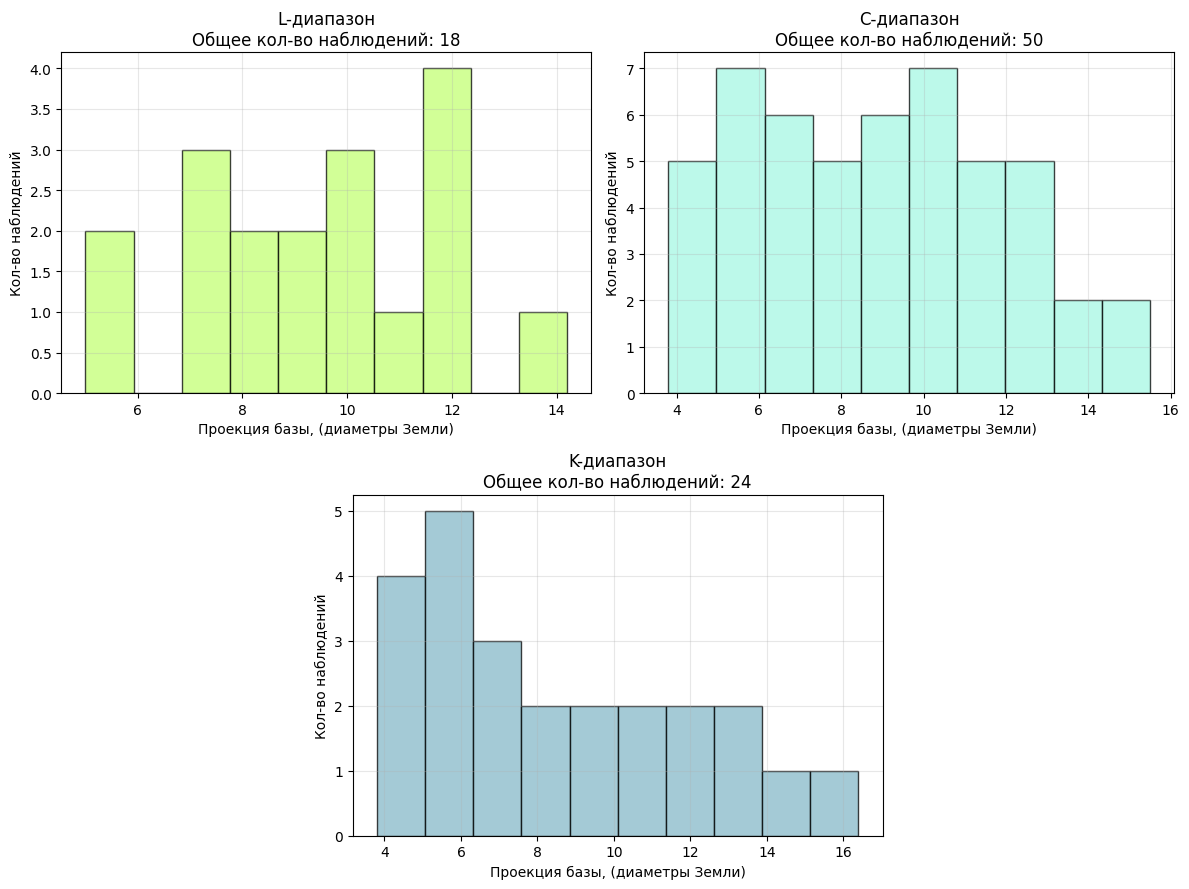

In [98]:
fig = plt.figure(figsize=(12, 9))

gs = fig.add_gridspec(2, 4)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

axes = [ax1, ax2, ax3]

for i in range(3):
    band = bands_without_p[i]
    ax = axes[i]
    data = df[df[band] == 1]

    if len(data) > 1:
        color = band_colors.get(band, 'steelblue')
        ax.hist(data['BL'], bins=10, alpha=0.75,
                color=color, edgecolor='black')
        ax.set_title(f'{band}-диапазон\nОбщее кол-во наблюдений: {len(data)}')
        ax.set_xlabel('Проекция базы, (диаметры Земли)')
        ax.set_ylabel('Кол-во наблюдений')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data.', ha='center', va='center')

plt.tight_layout()
plt.show()

In [99]:
results = []

for band in bands:
    if band not in df.columns:
        continue
    total = len(df)
    valid = df[band].notna().sum()
    n0 = (df[band] == 0).sum()
    n1 = (df[band] == 1).sum()
    n2 = (df[band] == 2).sum()
    
    results.append({
        'Band': band,
        'Observed': valid,
        '0 (no correlation)': n0,
        '1 (space-ground)': n1,
        '2 (ground only)': n2
    })

stats_df = pd.DataFrame(results)
print("Correlation statistics per band:")
print(f"Total observations: {total}")
print(stats_df.round(1).to_string(index=False))

Correlation statistics per band:
Total observations: 92
Band  Observed  0 (no correlation)  1 (space-ground)  2 (ground only)
   P         3                   1                 1                1
   L        36                  11                18                7
   C        76                   6                50               20
   K        54                   8                24               22


## Angular Size and Brightness Temperature

### Angular Size

**Comment**: perform statistical analysis of estimated angular size of the source obtained by standard Gaussian model fit.

#### Statistics

Angular Size Statistics:
                  Min_theta  Max_theta  Mean_theta  Median_theta  Std_theta  \
Sample      Band                                                              
All         C         0.076     12.375      1.0566        0.2500     2.0190   
            K         0.015      5.470      0.3514        0.0450     1.2416   
            L         0.390      9.866      2.2453        0.9795     2.9435   
Space Corr  C         0.076      3.224      0.6308        0.2320     0.7932   
            K         0.015      0.224      0.0558        0.0380     0.0580   
            L         0.390      9.866      2.3389        0.4565     3.3232   
Ground Corr C         1.453     12.375      5.2085        3.5030     4.8744   
            K         0.258      5.470      2.8640        2.8640     3.6854   
            L         1.472      2.270      1.8710        1.8710     0.5643   

                   N  
Sample      Band      
All         C     43  
            K     19  
            L

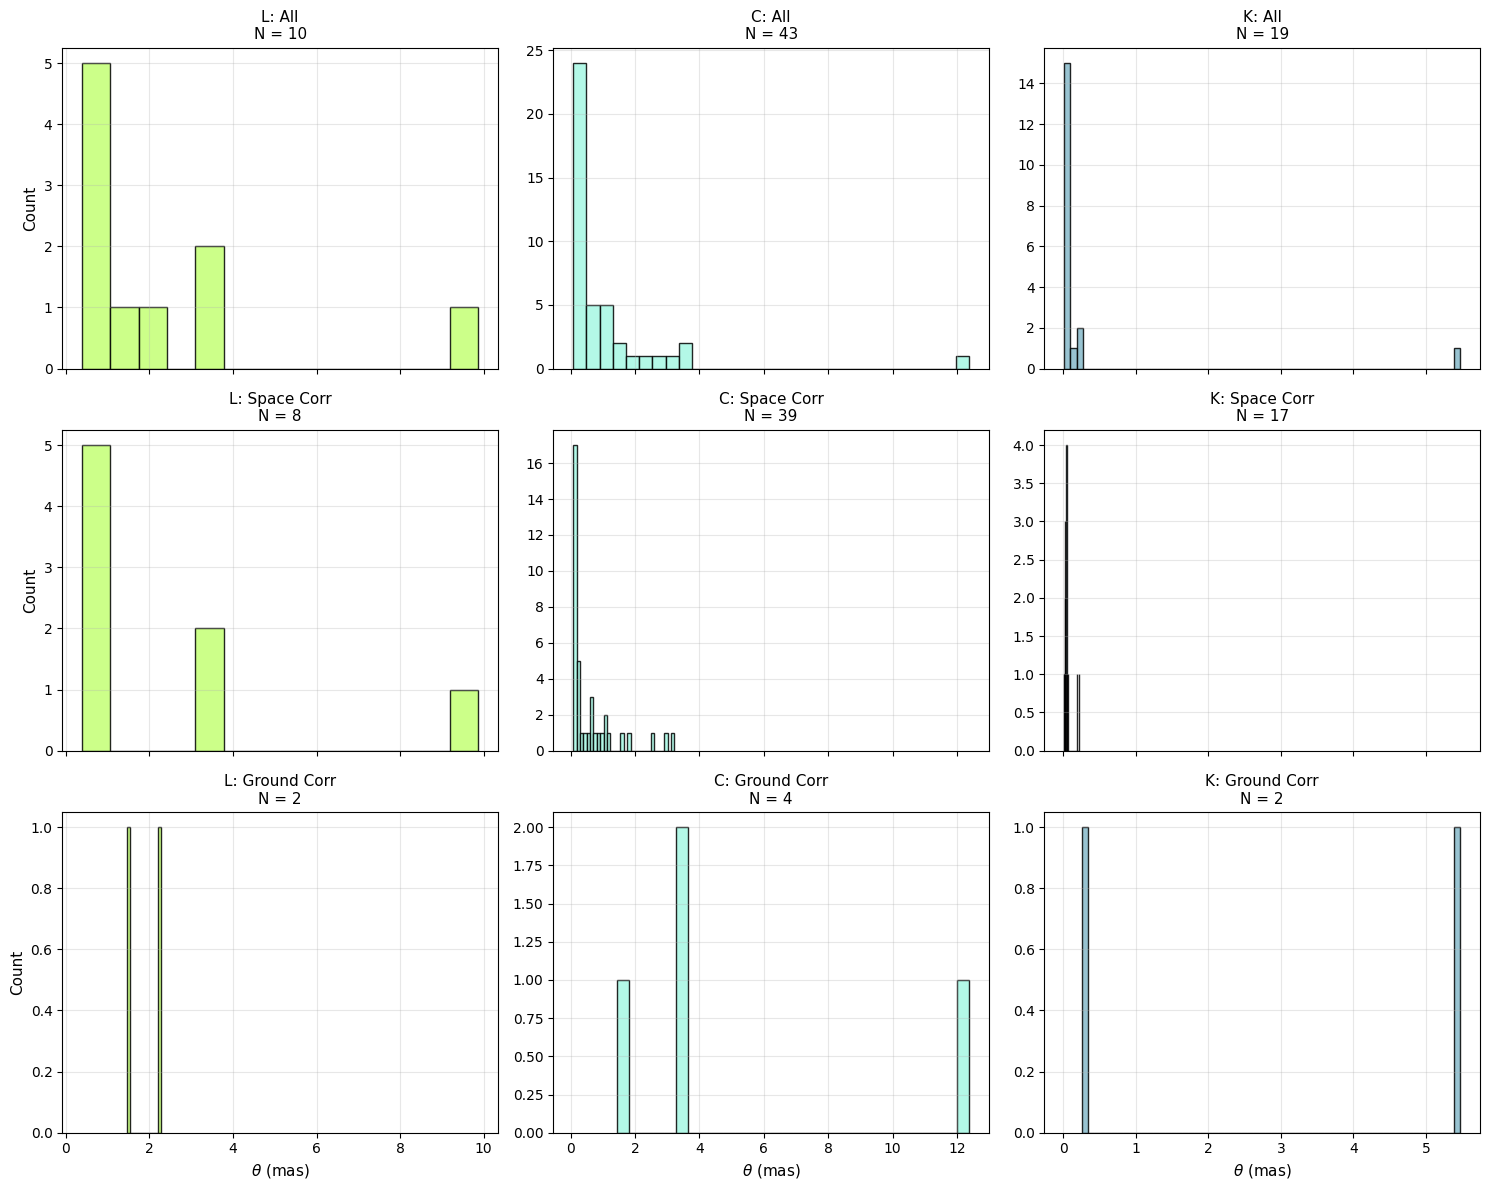

In [100]:
def theta_stats(data, label):
    stats = (
        data.groupby("Band")["Theta_mas"]
        .agg(["min", "max", "mean", "median", "std", "count"])
        .round(4)
        .rename(columns={
            "min": "Min_theta",
            "max": "Max_theta",
            "mean": "Mean_theta",
            "median": "Median_theta",
            "std": "Std_theta",
            "count": "N"
        })
    )
    stats["Sample"] = label
    return stats.reset_index()

stats_all = theta_stats(ang, "All")
stats_space = theta_stats(ang[ang["Corr"] == "1"], "Space Corr")
stats_ground = theta_stats(ang[ang["Corr"] != "1"], "Ground Corr")

stats = pd.concat([stats_all, stats_space, stats_ground], ignore_index=True)
stats = stats.set_index(["Sample", "Band"])

print("Angular Size Statistics:")
print(stats)

# =======================
# Гистограммы
# =======================
bins_dict = {
    'L': 14,
    'C': 30,
    'K': 64
}

datasets = [
    ("All", ang),
    ("Space Corr", ang[ang["Corr"] == "1"]),
    ("Ground Corr", ang[ang["Corr"] != "1"]),
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 12),
    sharex='col',
    sharey=False
)

for row, (label, data) in enumerate(datasets):
    for col, band in enumerate(bands_without_p):  # ['L', 'C', 'K']
        ax = axes[row, col]

        subset = data.loc[data["Band"] == band, "Theta_mas"]

        if len(subset):
            ax.hist(
                subset,
                bins=bins_dict[band],
                color=band_colors.get(band, "steelblue"),
                edgecolor="black",
                alpha=0.85
            )

            ax.set_title(f"{band}: {label}\nN = {len(subset)}", fontsize=11)
            ax.grid(True, alpha=0.3)
        else:
            ax.text(
                0.5, 0.5, "No data",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

        if row == 2:
            ax.set_xlabel(r"$\theta$ (mas)", fontsize=11)

        if col == 0:
            ax.set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()

#### Frequency Dependency

--------------------------------
Frequency dependence of angular size
--------------------------------
Slope = -1.2032 ± 0.1795
ALPHA = 1.2032 ± 0.1795
Intercept = 4.0294 ± 0.6844
R² = 0.3909


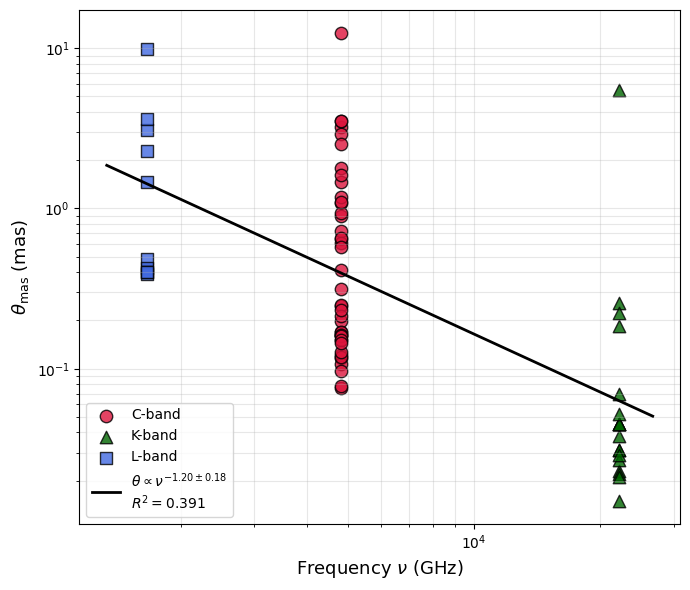

In [122]:
colors = {
    "L": "royalblue",
    "C": "crimson",
    "K": "darkgreen"
}

markers = {
    "L": "s",
    "C": "o",
    "K": "^"
}

dfa = ang.copy()
dfa = dfa[
    (dfa["Frequency"] > 0) &
    (dfa["Theta_mas"] > 0)
]


x = np.log10(dfa["Frequency"].values)
y = np.log10(dfa["Theta_mas"].values)


# Линейная регрессия с оценкой ковариационной матрицы
coeffs, cov = np.polyfit(x, y, 1, cov=True)

a, b = coeffs

# 1σ ошибки коэффициентов
a_err = np.sqrt(cov[0, 0])
b_err = np.sqrt(cov[1, 1])

alpha = -a
alpha_err = a_err
y_fit = a*x + b

ss_res = np.sum((y-y_fit)**2)
ss_tot = np.sum((y-np.mean(y))**2)

R2 = 1 - ss_res/ss_tot

alpha = -a


print("--------------------------------")
print("Frequency dependence of angular size")
print("--------------------------------")
print(f"Slope = {a:.4f} ± {a_err:.4f}")
print(f"ALPHA = {alpha:.4f} ± {alpha_err:.4f}")
print(f"Intercept = {b:.4f} ± {b_err:.4f}")
print(f"R² = {R2:.4f}")


fig, ax = plt.subplots(figsize=(7,6))

for band in sorted(dfa["Band"].unique()):

    m = dfa["Band"] == band

    ax.scatter(
        dfa.loc[m,"Frequency"],
        dfa.loc[m,"Theta_mas"],
        s=80,
        marker=markers.get(band,"o"),
        color=colors.get(band,"gray"),
        edgecolor="k",
        alpha=0.8,
        label=f"{band}-band"
    )

nu_line = np.logspace(
    np.log10(dfa["Frequency"].min()*0.8),
    np.log10(dfa["Frequency"].max()*1.2),
    200
)

theta_line = 10**(
    a*np.log10(nu_line)+b
)

ax.plot(
    nu_line,
    theta_line,
    color="black",
    lw=2,
    label=(
    rf"$\theta \propto \nu^{{-{alpha:.2f}\pm{alpha_err:.2f}}}$"
    "\n"
    rf"$R^2={R2:.3f}$"
)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(
    r"Frequency $\nu$ (GHz)",
    fontsize=13
)

ax.set_ylabel(
    r"$\theta_{\rm mas}$ (mas)",
    fontsize=13
)

ax.grid(
    alpha=0.3,
    which="both"
)

ax.legend()

plt.tight_layout()
plt.show()

--------------------------------
Frequency dependence of median angular size
--------------------------------
Slope = -1.1847 ± 0.0448
ALPHA = 1.1847 ± 0.0448
Intercept = 3.7910 ± 0.1694
R² = 0.9986


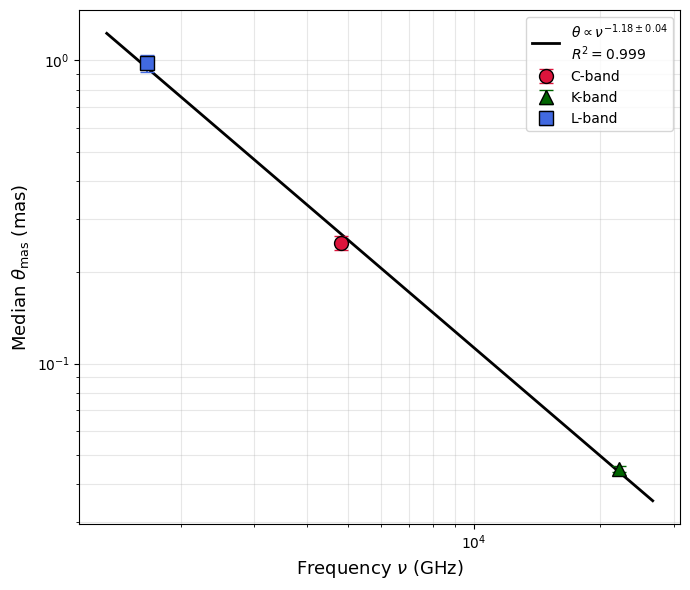

In [121]:
colors = {
    "L": "royalblue",
    "C": "crimson",
    "K": "darkgreen"
}

markers = {
    "L": "s",
    "C": "o",
    "K": "^"
}

# =======================
# Медианные значения по диапазонам
# =======================
med = (
    ang.groupby(["Band", "Frequency"], as_index=False)
       .agg(
           Median_theta=("Theta_mas", "median"),
           Median_theta_err=("Theta_mas_err", "median"),
           N=("Theta_mas", "count")
       )
)

# =======================
# Регрессия
# =======================
x = np.log10(med["Frequency"].values)
y = np.log10(med["Median_theta"].values)

# Линейная регрессия с оценкой ковариационной матрицы
coeffs, cov = np.polyfit(x, y, 1, cov=True)

a, b = coeffs

# 1σ ошибки коэффициентов
a_err = np.sqrt(cov[0, 0])
b_err = np.sqrt(cov[1, 1])

alpha = -a
alpha_err = a_err

y_fit = a * x + b

ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
R2 = 1 - ss_res / ss_tot

alpha = -a

print("--------------------------------")
print("Frequency dependence of median angular size")
print("--------------------------------")
print(f"Slope = {a:.4f} ± {a_err:.4f}")
print(f"ALPHA = {alpha:.4f} ± {alpha_err:.4f}")
print(f"Intercept = {b:.4f} ± {b_err:.4f}")
print(f"R² = {R2:.4f}")

# =======================
# Plot
# =======================

fig, ax = plt.subplots(figsize=(7,6))

for _, row in med.iterrows():

    ax.errorbar(
        row["Frequency"],
        row["Median_theta"],
        yerr=row["Median_theta_err"],
        fmt=markers.get(row["Band"], "o"),
        markersize=10,
        color=colors.get(row["Band"], "gray"),
        markeredgecolor="k",
        markeredgewidth=1,
        capsize=5,
        elinewidth=1.5,
        zorder=3,
        label=f'{row["Band"]}-band'
    )

nu_line = np.logspace(
    np.log10(med["Frequency"].min()*0.8),
    np.log10(med["Frequency"].max()*1.2),
    200
)

theta_line = 10**(a*np.log10(nu_line)+b)

ax.plot(
    nu_line,
    theta_line,
    color="black",
    lw=2,
    label=(
    rf"$\theta \propto \nu^{{-{alpha:.2f}\pm{alpha_err:.2f}}}$"
    "\n"
    rf"$R^2={R2:.3f}$"
)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Frequency $\nu$ (GHz)", fontsize=13)
ax.set_ylabel(r"Median $\theta_{\rm mas}$ (mas)", fontsize=13)

ax.grid(alpha=0.3, which="both")

# убрать дубли в легенде
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

С: 9.70065E-10 ± 8.14622E-11
K: 2.51947E-10 ± 5.22922E-11
L: 9.32129E-9 ± 8.45226E-10

--------------------------------
Frequency dependence of angular size
--------------------------------
Slope = -1.3585 ± 0.3445
ALPHA = 1.3585 ± 0.3445
Intercept = 4.5295 ± 1.3020
R² = 0.9396


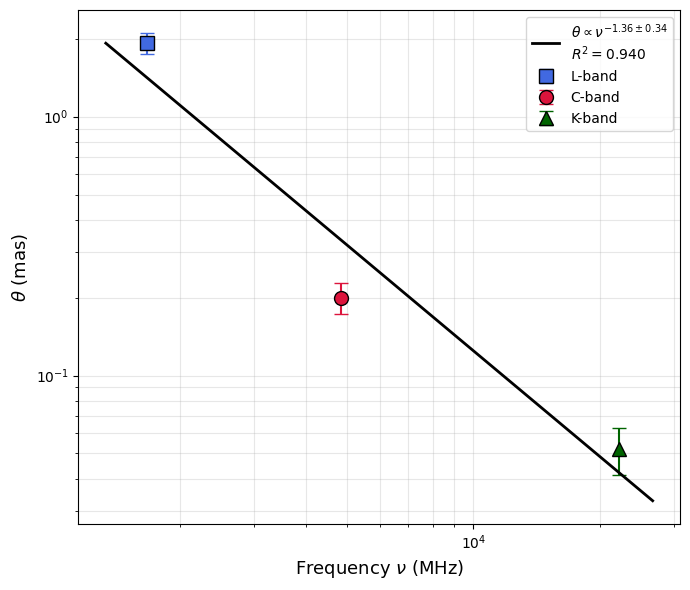

In [120]:
colors = {
    "L": "royalblue",
    "C": "crimson",
    "K": "darkgreen"
}

markers = {
    "L": "s",
    "C": "o",
    "K": "^"
}

# ==========================================
# Данные
# ==========================================

fit = pd.DataFrame({
    "Band": ["L", "C", "K"],
    "Frequency": [1668, 4828, 22236],      # MHz
    "Theta_mas": [1.92318, 0.20012, 0.05197],
    "Theta_err": [0.17432, 0.02680, 0.01079]
})

# ==========================================
# Регрессия
# ==========================================

x = np.log10(fit["Frequency"])
y = np.log10(fit["Theta_mas"])

# Линейная регрессия с оценкой ковариационной матрицы
coeffs, cov = np.polyfit(x, y, 1, cov=True)

a, b = coeffs

# 1σ ошибки коэффициентов
a_err = np.sqrt(cov[0, 0])
b_err = np.sqrt(cov[1, 1])

alpha = -a
alpha_err = a_err

y_fit = a * x + b

ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - ss_res / ss_tot

alpha = -a

print("--------------------------------")
print("Frequency dependence of angular size")
print("--------------------------------")
print(f"Slope = {a:.4f} ± {a_err:.4f}")
print(f"ALPHA = {alpha:.4f} ± {alpha_err:.4f}")
print(f"Intercept = {b:.4f} ± {b_err:.4f}")
print(f"R² = {R2:.4f}")

# ==========================================
# Plot
# ==========================================

fig, ax = plt.subplots(figsize=(7,6))

for _, row in fit.iterrows():

    ax.errorbar(
        row["Frequency"],
        row["Theta_mas"],
        yerr=row["Theta_err"],
        fmt=markers[row["Band"]],
        color=colors[row["Band"]],
        markeredgecolor="k",
        markersize=10,
        capsize=5,
        lw=1.5,
        label=f'{row["Band"]}-band'
    )

nu_line = np.logspace(
    np.log10(fit["Frequency"].min()*0.8),
    np.log10(fit["Frequency"].max()*1.2),
    200
)

theta_line = 10**(a*np.log10(nu_line)+b)

ax.plot(
    nu_line,
    theta_line,
    color="black",
    lw=2,
    label=(
    rf"$\theta \propto \nu^{{-{alpha:.2f}\pm{alpha_err:.2f}}}$"
    "\n"
    rf"$R^2={R2:.3f}$"
)
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Frequency $\nu$ (MHz)", fontsize=13)
ax.set_ylabel(r"$\theta$ (mas)", fontsize=13)

ax.grid(True, which="both", alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()

### Brightness Temperature

**Comment:** estimating $T_b$ from measured angular size & correlated flux.

#### Estimates

**Comment**: adding to __ang__ new column with $T_b$.

In [103]:
S = ang["A0"].astype(float)
S_err = ang["A0_err"].astype(float)

nu = ang["Frequency"].astype(float) / 1000.0

theta = ang["Theta_mas"].astype(float)
theta_err = ang["Theta_mas_err"].astype(float)

Tb = 1.22e12 * S / (nu**2 * theta**2)

Tb_err = Tb * np.sqrt(
    (S_err / S)**2 +
    (2 * theta_err / theta)**2
)

ang["Tb"] = Tb
ang["Tb_err"] = Tb_err

display(ang.head())

,Obs,Band,Date,Frequency,Theta_rad,Theta_rad_err,Theta_mas,Theta_mas_err,Y0,Y0_err,A0,A0_err,BL_ED,Corr,Tb,Tb_err
0,RAES03AA,C,2012-04-27,4828,5.623820e-10,6.043870e-12,0.116,0.001,0.00000,0.00000,1.82470,0.01301,12.0,1,7.097425e+12,1.324200e+11
1,RAES03AB,C,2012-04-28,4828,8.223090e-10,3.783600e-11,0.170,0.008,0.00000,0.00000,1.41168,0.01634,9.0,1,2.556606e+12,2.424345e+11
2,RAES03FW,C,2012-11-19,4828,3.105990e-09,9.651350e-10,0.641,0.199,0.04239,0.00535,2.34019,0.29095,10.0,1,2.980989e+11,1.887651e+11
3,RAES03FW,L,2012-11-19,1668,2.360400e-09,3.565680e-11,0.487,0.007,0.00000,0.00000,1.65010,0.00562,10.0,1,3.050845e+12,8.831733e+10
4,RAES03P,C,2012-04-04,4828,1.197850e-09,8.629210e-11,0.247,0.018,0.00000,0.00000,3.60793,0.05398,5.0,1,3.095206e+12,4.534937e+11


#### Statistics

**Comment**: provide descriptive statistics for estimated $T_b$.

Brightness Temperature Statistics:
                        Min_Tb        Max_Tb       Mean_Tb     Median_Tb  \
Sample      Band                                                           
All         C     1.938496e+09  8.782275e+12  2.101957e+12  1.511585e+12   
            K     3.628478e+08  1.353323e+13  3.127720e+12  1.645532e+12   
            L     9.011384e+09  9.933799e+12  2.634048e+12  1.715442e+12   
Space Corr  C     1.902558e+10  8.782275e+12  2.314636e+12  1.542688e+12   
            K     7.209465e+10  1.353323e+13  3.483737e+12  2.113345e+12   
            L     9.011384e+09  9.933799e+12  3.226167e+12  3.340694e+12   
Ground Corr C     1.938496e+09  9.444256e+10  2.834166e+10  8.492792e+09   
            K     3.628478e+08  2.027901e+11  1.015765e+11  1.015765e+11   
            L     1.511014e+11  3.800399e+11  2.655707e+11  2.655707e+11   

                        Std_Tb   N  
Sample      Band                    
All         C     2.395799e+12  43  
            K    

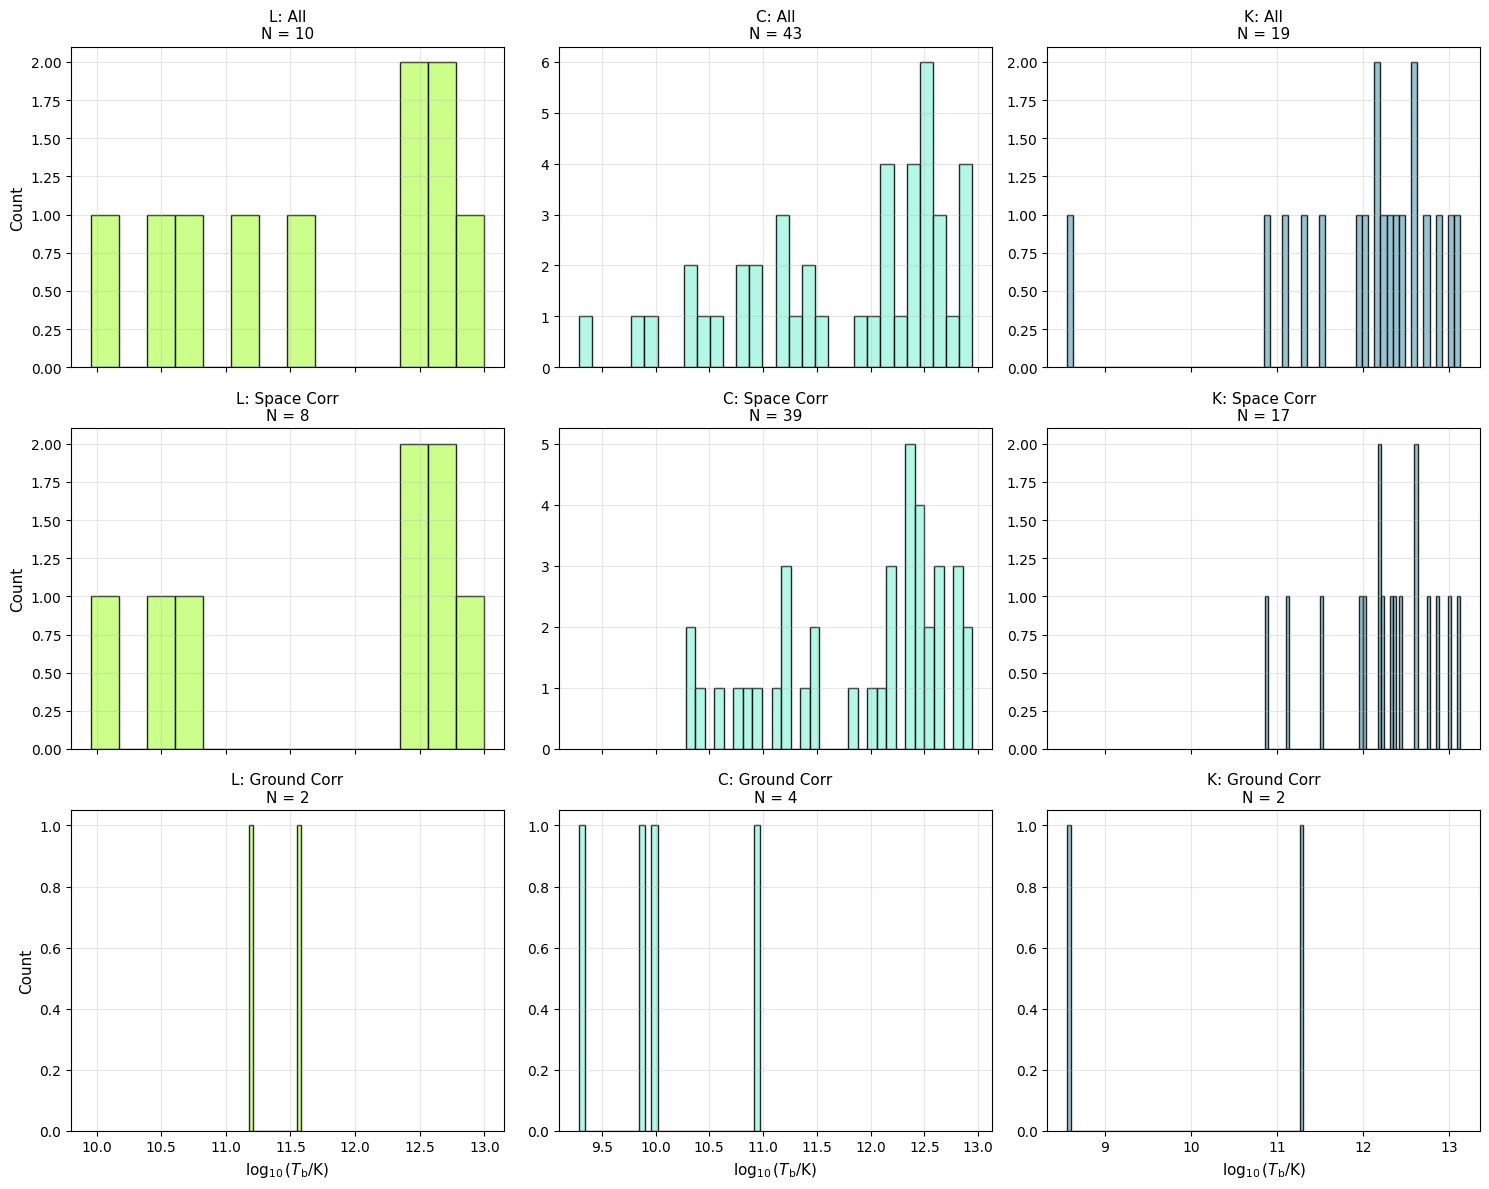

In [109]:
def tb_stats(data, label):
    stats = (
        data.groupby("Band")["Tb"]
        .agg(["min", "max", "mean", "median", "std", "count"])
        .round(4)
        .rename(columns={
            "min": "Min_Tb",
            "max": "Max_Tb",
            "mean": "Mean_Tb",
            "median": "Median_Tb",
            "std": "Std_Tb",
            "count": "N"
        })
    )
    stats["Sample"] = label
    return stats.reset_index()

# =======================
# Статистика
# =======================
stats_all = tb_stats(ang, "All")
stats_space = tb_stats(ang[ang["Corr"] == "1"], "Space Corr")
stats_ground = tb_stats(ang[ang["Corr"] != "1"], "Ground Corr")

stats = pd.concat(
    [stats_all, stats_space, stats_ground],
    ignore_index=True
).set_index(["Sample", "Band"])

print("Brightness Temperature Statistics:")
print(stats)

# =======================
# Гистограммы
# =======================
bins_dict = {
    'L': 14,
    'C': 30,
    'K': 64
}

datasets = [
    ("All", ang),
    ("Space Corr", ang[ang["Corr"] == "1"]),
    ("Ground Corr", ang[ang["Corr"] != "1"]),
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 12),
    sharex='col',
    sharey=False
)

for row, (label, data) in enumerate(datasets):
    for col, band in enumerate(bands_without_p):   # ['L', 'C', 'K']

        ax = axes[row, col]

        subset = np.log10(
            data.loc[data["Band"] == band, "Tb"]
        )

        if len(subset):

            ax.hist(
                subset,
                bins=bins_dict[band],
                color=band_colors.get(band, "steelblue"),
                edgecolor="black",
                alpha=0.85
            )

            ax.set_title(f"{band}: {label}\nN = {len(subset)}", fontsize=11)
            ax.grid(True, alpha=0.3)

        else:

            ax.text(
                0.5,
                0.5,
                "No data",
                ha="center",
                va="center",
                transform=ax.transAxes
            )

        if row == 2:
            ax.set_xlabel(r'$\log_{10}(T_{\mathrm{b}}/\mathrm{K})$', fontsize=11)

        if col == 0:
            ax.set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()

## Light Curves

Add here comparison of brightness temperature vs. light curves at different bands (RATAN, photometry, X-ray, gamma-ray, etc.)

In [105]:
fermit = fermit.copy()
fermit["JD"] = fermit.iloc[:, 0] + 2400000.5

swift = swift.copy()
swift["JD"] = swift["BinCenter"] + 2400000.5

ang = ang.copy()
ang["JD"] = pd.to_datetime(ang["Date"]).apply(
    lambda x: x.to_julian_date()
)

ra_dates = np.sort(ang["JD"].unique())

In [106]:
ang = ang.copy()
df = df.copy()

ang["JD"] = pd.to_datetime(ang["Date"]).apply(
    lambda x: x.to_julian_date()
)

ang["Obs"] = (
    ang["Obs"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df["Obs. Code"] = (
    df["Obs. Code"]
    .astype(str)
    .str.strip()
    .str.upper()
)

ra_sessions = (
    ang[["Obs", "JD"]]
    .drop_duplicates()
    .merge(
        df[["Obs. Code", "BL"]]
        .drop_duplicates("Obs. Code"),
        left_on="Obs",
        right_on="Obs. Code",
        how="left"
    )
    .rename(columns={"BL": "Baseline_ED"})
)

ra_dates = ra_sessions["JD"].values

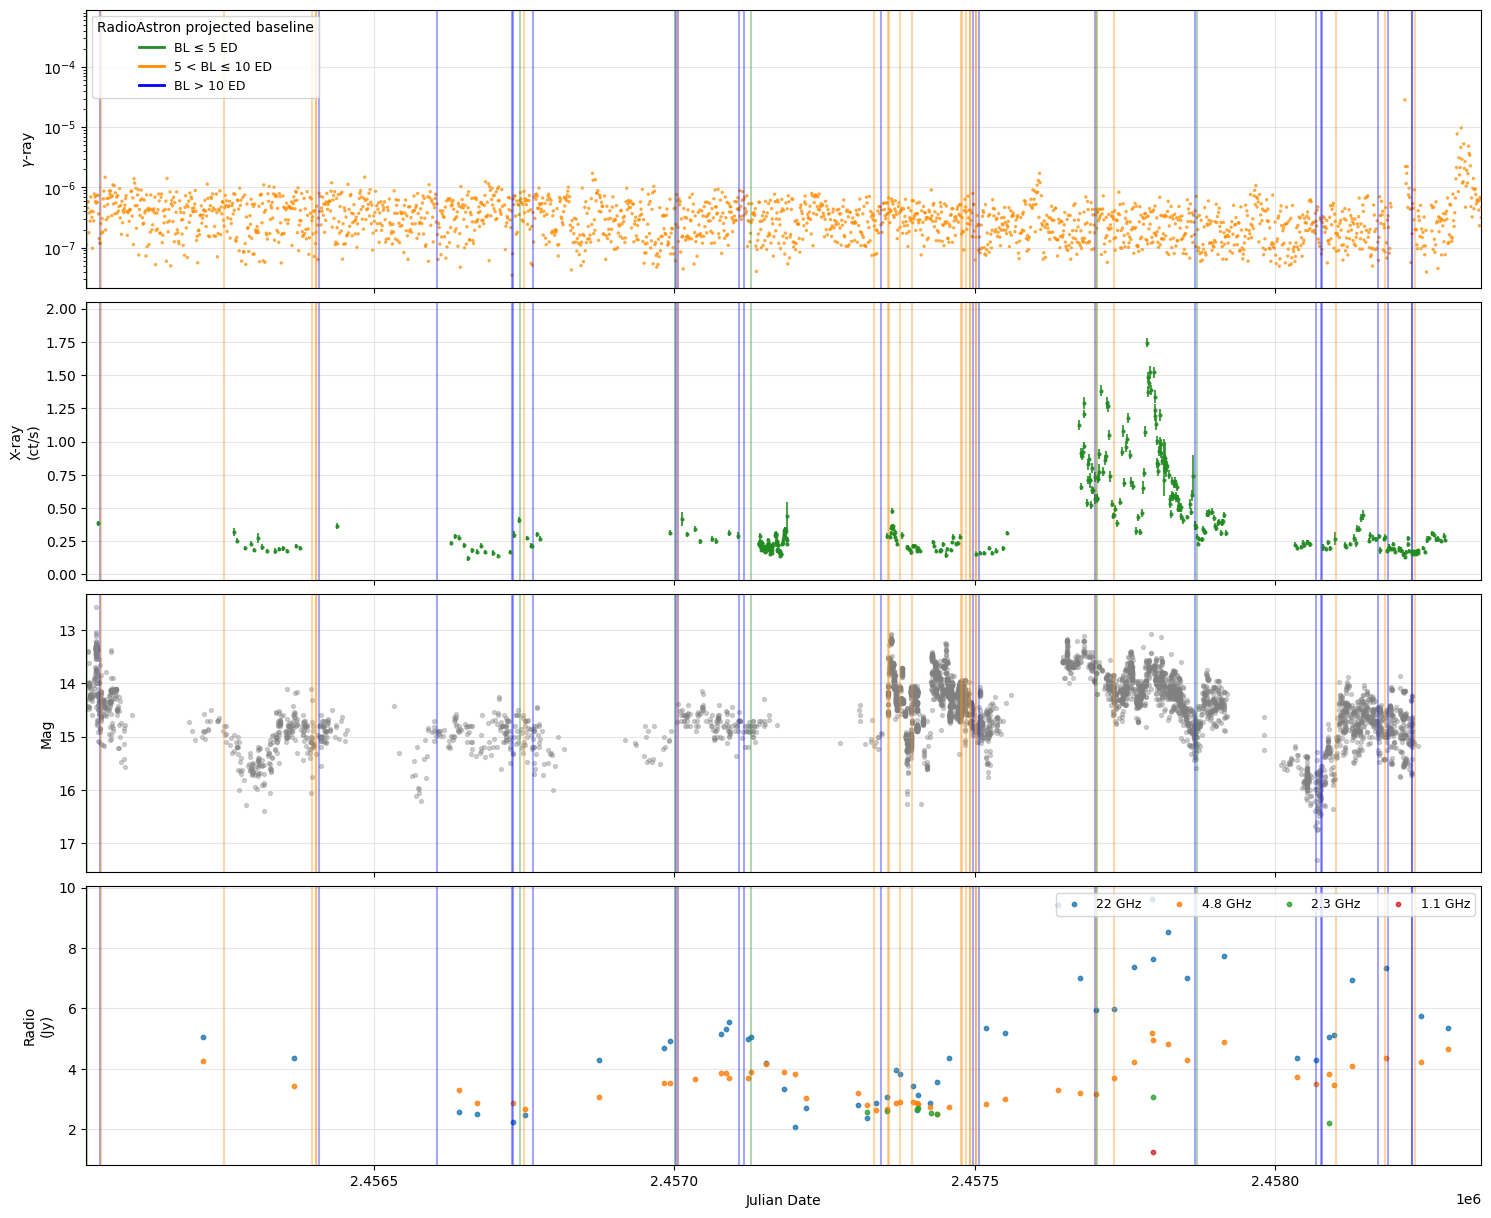

In [107]:
xmin = ra_dates.min()
xmax = ra_dates.max()

margin = 0.05 * (xmax - xmin)

def baseline_color(bl):
    if pd.isna(bl):
        return "gray"
    elif bl <= 5:
        return "forestgreen"
    elif bl <= 10:
        return "darkorange"
    else:
        return "blue"

fig, axes = plt.subplots(
    4,
    1,
    figsize=(18, 15),
    sharex=True,
    gridspec_kw={"hspace": 0.05}
)

ax0, ax1, ax2, ax3 = axes

# FERMI

ax0.scatter(
    fermit["JD"],
    fermit["FLUX_100_300000"],
    s=6,
    color="darkorange",
    alpha=0.75,
    edgecolors="none",
)

ax0.set_yscale("log")
ax0.set_ylabel(r"$\gamma$-ray")
ax0.grid(alpha=0.3)

# SWIFT

mask = swift["RateError"] > 0

ax1.errorbar(
    swift.loc[mask, "JD"],
    swift.loc[mask, "Rate"],
    yerr=swift.loc[mask, "RateError"],
    fmt=".",
    color="forestgreen",
    alpha=0.8,
    markersize=4,
)

ax1.set_ylabel("X-ray\n(ct/s)")
ax1.grid(alpha=0.3)

# OPTICAL

ax2.scatter(
    flux["JD"],
    flux["Magnitude"],
    s=8,
    color="gray",
    alpha=0.35,
)

ax2.invert_yaxis()
ax2.set_ylabel("Mag")
ax2.grid(alpha=0.3)

# RATAN

ax3.scatter(
    ratan["JD"],
    ratan["Flux_22"],
    s=10,
    label="22 GHz",
    alpha=0.8,
)

ax3.scatter(
    ratan["JD"],
    ratan["Flux_4"],
    s=10,
    label="4.8 GHz",
    alpha=0.8,
)

ax3.scatter(
    ratan["JD"],
    ratan["Flux_2"],
    s=10,
    label="2.3 GHz",
    alpha=0.8,
)

ax3.scatter(
    ratan["JD"],
    ratan["Flux_1"],
    s=10,
    label="1.1 GHz",
    alpha=0.8,
)

ax3.set_ylabel("Radio\n(Jy)")
ax3.legend(
    ncol=4,
    fontsize=9,
    loc="upper right"
)
ax3.grid(alpha=0.3)

# RADIOASTRON EPOCHS

for ax in axes:

    ax.set_xlim(xmin, xmax + margin)

    for _, row in ra_sessions.iterrows():

        ax.axvline(
            row["JD"],
            color=baseline_color(row["Baseline_ED"]),
            alpha=0.35,
            lw=1.5
        )

# LEGEND FOR RADIOASTRON BASELINES

baseline_legend = [
    Line2D([0], [0],
           color="forestgreen",
           lw=2,
           label="BL ≤ 5 ED"),

    Line2D([0], [0],
           color="darkorange",
           lw=2,
           label="5 < BL ≤ 10 ED"),

    Line2D([0], [0],
           color="blue",
           lw=2,
           label="BL > 10 ED"),
]

ax0.legend(
    handles=baseline_legend,
    title="RadioAstron projected baseline",
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

ax3.set_xlabel("Julian Date")

plt.show()

## Multi-frequency Spectral Index analysis

**Comment**: estimate and analyze spectral index for observations with 2 simoultaneous bands.

In [125]:
results = []

for obs, g in ang.groupby("Obs"):

    # только корректные значения
    g = g[
        (g["Frequency"] > 0) &
        (g["A0"] > 0) &
        (g["A0_err"] > 0)
    ]

    # нужны ровно две частоты
    if len(g) != 2:
        continue

    # сортируем по частоте
    g = g.sort_values("Frequency")

    nu1, nu2 = g["Frequency"].values
    S1, S2 = g["A0"].values
    eS1, eS2 = g["A0_err"].values

    # спектральный индекс
    alpha = np.log(S2/S1) / np.log(nu2/nu1)

    # ошибка
    alpha_err = (
        1 / np.log(nu2/nu1)
        *
        np.sqrt(
            (eS1/S1)**2 +
            (eS2/S2)**2
        )
    )

    results.append({
        "Obs": obs,
        "Bands": "-".join(g["Band"].values),
        "Nbands": 2,
        "nu1": nu1,
        "nu2": nu2,
        "A1": S1,
        "A2": S2,
        "Alpha": alpha,
        "Alpha_err": alpha_err
    })


spec_index = pd.DataFrame(results)


print("--------------------------------")
print("Compact core spectral index from A0")
print("--------------------------------")

print(spec_index)

print("\nStatistics:")
print(f"N = {len(spec_index)}")
print(f"Mean alpha = {spec_index['Alpha'].mean():.3f} ± {spec_index['Alpha'].std():.3f}")
print(f"Median alpha = {spec_index['Alpha'].median():.3f}")

--------------------------------
Compact core spectral index from A0
--------------------------------
         Obs Bands  Nbands   nu1    nu2        A1       A2     Alpha  \
0   RAES03FW   L-C       2  1668   4828   1.65010  2.34019  0.328749   
1   RAES03RL   C-K       2  4828  22236   2.59963  1.63149 -0.305036   
2   RAKS01IQ   L-C       2  1668   4828   1.50253  4.16006  0.958198   
3   RAKS01XF   C-K       2  4828  22236   1.83305  1.91572  0.028883   
4   RAKS01ZM   C-K       2  4828  22236   0.96919  0.89711 -0.050601   
5   RAKS08JM   L-C       2  1668   4828   1.77563  1.76527 -0.005506   
6   RAKS08JQ   C-K       2  4828  22236   1.45163  2.90142  0.453429   
7   RAKS08TO   C-K       2  4828  22236   2.05241  1.43303 -0.235205   
8   RAKS08VQ   C-K       2  4828  22236   2.90611  0.78309 -0.858600   
9   RAKS12JM   C-K       2  4828  22236   1.44902  0.40262 -0.838516   
10  RAKS12SY   C-K       2  4828  22236   1.26128  0.82309 -0.279462   
11  RAKS12VB   C-K       2  4828  

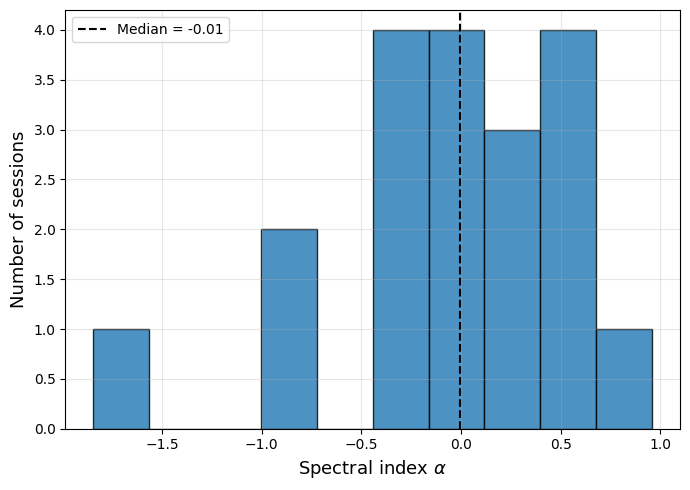

In [126]:
fig, ax = plt.subplots(figsize=(7,5))

ax.hist(
    spec_index["Alpha"],
    bins=10,
    edgecolor="black",
    alpha=0.8
)

ax.axvline(
    spec_index["Alpha"].median(),
    color="black",
    linestyle="--",
    label=f"Median = {spec_index['Alpha'].median():.2f}"
)

ax.set_xlabel(r"Spectral index $\alpha$", fontsize=13)
ax.set_ylabel("Number of sessions", fontsize=13)

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()
plt.show()

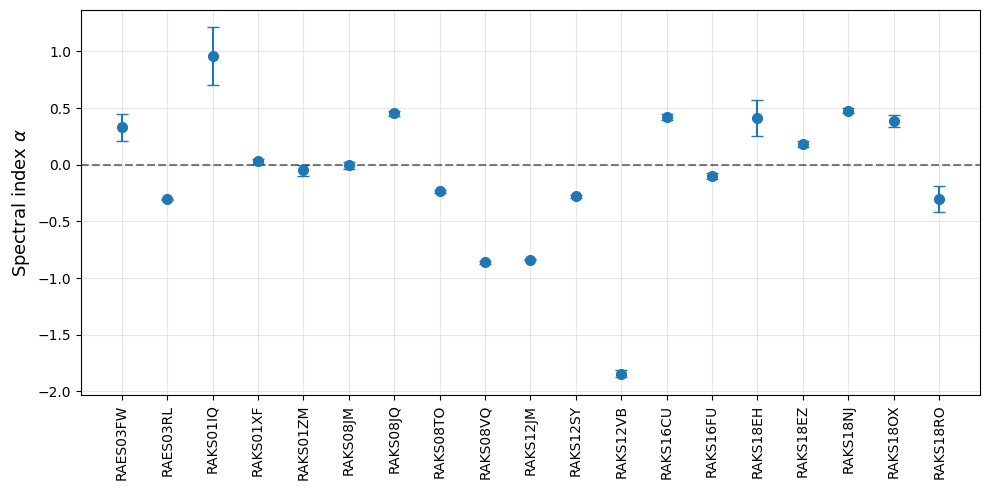

In [127]:
fig, ax = plt.subplots(figsize=(10,5))

x = np.arange(len(spec_index))

ax.errorbar(
    x,
    spec_index["Alpha"],
    yerr=spec_index["Alpha_err"],
    fmt="o",
    capsize=4,
    markersize=7
)

ax.axhline(
    0,
    color="black",
    linestyle="--",
    alpha=0.5
)

ax.set_xticks(x)
ax.set_xticklabels(
    spec_index["Obs"],
    rotation=90
)

ax.set_ylabel(
    r"Spectral index $\alpha$",
    fontsize=13
)

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

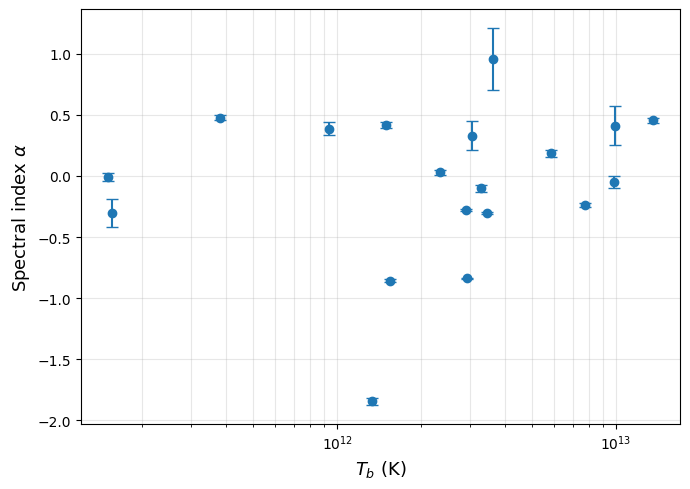

In [128]:
tmp = (
    spec_index
    .merge(
        ang.groupby("Obs")["Tb"].max().reset_index(),
        on="Obs",
        how="left"
    )
)

fig, ax = plt.subplots(figsize=(7,5))

ax.errorbar(
    tmp["Tb"],
    tmp["Alpha"],
    yerr=tmp["Alpha_err"],
    fmt="o",
    capsize=4
)

ax.set_xscale("log")

ax.set_xlabel(
    r"$T_b$ (K)",
    fontsize=13
)

ax.set_ylabel(
    r"Spectral index $\alpha$",
    fontsize=13
)

ax.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()